# Astr 324, Spring 2026, University of Washington


# Week 7:  Time Series Analysis

#### This notebook is available from [github](https://github.com/uw-astr-324/astr-324-s26/blob/main/lectures/Week7.ipynb).

# Packages

- make sure that `pymc`, `astroML`, and `gatspy` are installed:  
```
conda install -c defaults -c astropy astroML
conda install -c defaults -c conda-forge pymc gatspy
```

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
#import pymc as pm
from astroML.plotting.mcmc import plot_mcmc
np.random.seed(42)

In [2]:
print(np.__version__)

2.0.2


In [3]:
# To remain consistent with the textbook, we'll use some functions that have 
# been deprecated in recent versions of astroML. This code silences the
# distracting deprecation warnings related to these.

import warnings
from astroML.utils.exceptions import AstroMLDeprecationWarning
warnings.filterwarnings("ignore", category=AstroMLDeprecationWarning)

Eyer and Mowlavi (2007, arXiv:0712.3797) 
<img src="figures/EyerMowlavi2007.png" style="float: left; width: 90%; margin-right: 1%;"> 

# Time Series Analysis

**Time series** is a set of measurements of some properties of an object as a function of time. When those properties are the flux or the magnitude, we call such time series a **light curve**.

When it comes to light curves, there is a broad range of variability signatures that we are aware of: from transient events to periodic variables to stochastic sources. Time series analysis allows us to characterize these different types of variability.

Here are a few examples of light curves:

<img src="figures/flare.png" style="float: left; width: 30%; margin-right: 1%;">
<img src="figures/cepheid.png" style="float: left; width: 30%; margin-right: 1%;">
<img src="figures/eclipsing.png" style="float: left; width: 30%; margin-right: 1%;">

## Goals

The goal of time series analysis is to understand the patterns (if any) of time variability of an object.

1. The first thing that we want to know is if the system that we are studying is even variable (otherwise, there is no point doing time series analysis!).

1. If we find that our source *is* variable, then we wish to characterize the variation. For example we wish to know whether the variation is periodic (and what is the period), what is the amplitude of variation, the shape, etc.

In [4]:
#------------------------------------------------------------
# Generate Data
np.random.seed(42)

def makeData(N, b0, sig, P, A): 
    # simulate observations taken during nighttime
    t = np.random.randint(100, size=N) + 0.3 + 0.4 * np.random.random(N)
    y = b0 + A*np.sin(2 * np.pi * t / P)
    dy = t*0 + sig
    y_obs = np.random.normal(y, dy)
    chi2dof = 1/(N-1) * np.sum((y_obs-np.mean(y_obs))**2/dy**2)
    print("chi2 per degree of freedom:", chi2dof)
    print("expected scatter in chi2dof:", np.sqrt(2/N))
    print("observed chi2dof departs from 1 by this many sigmas:", np.abs(1-chi2dof)/np.sqrt(2/N))
    return t, y, y_obs, dy 

def plotLC(time, yObs, yErr):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.errorbar(time, yObs, yErr, fmt='.k', lw=1, ecolor='gray')
    ax.set_xlabel('time (days)')
    ax.set_ylabel('flux')
    ax.set_xlim(-5, 105);

chi2 per degree of freedom: 0.8360874642880808
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 1.1590366552338023


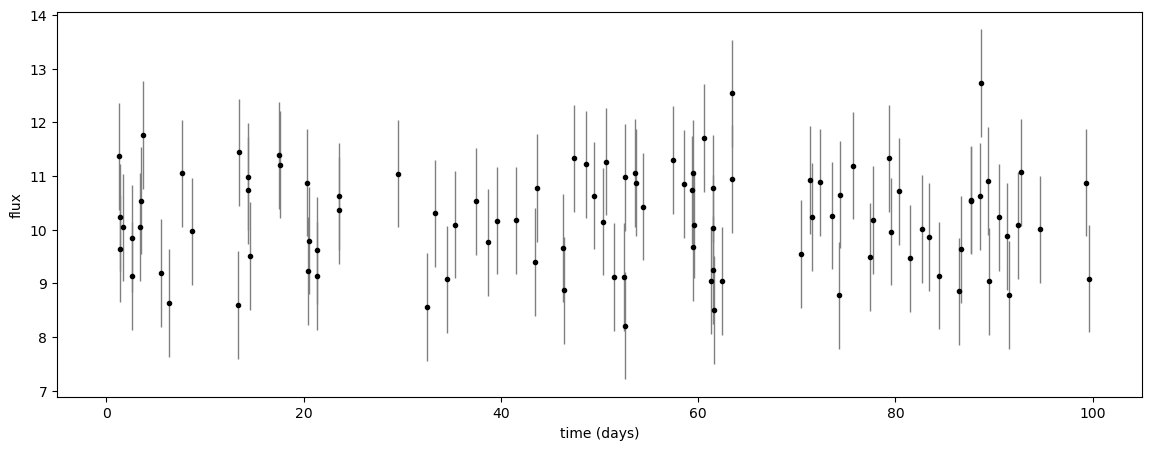

In [5]:
N = 100
P = 0.3 # period is 0.3 days 
sig = 1.0
A = 0.0
b0 = 10.0 
time, y, yObs, yErr = makeData(N, b0, sig, P, A)
# plot the results
plotLC(time, yObs, yErr)

chi2 per degree of freedom: 1.3792156753684623
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 2.6814597558527615


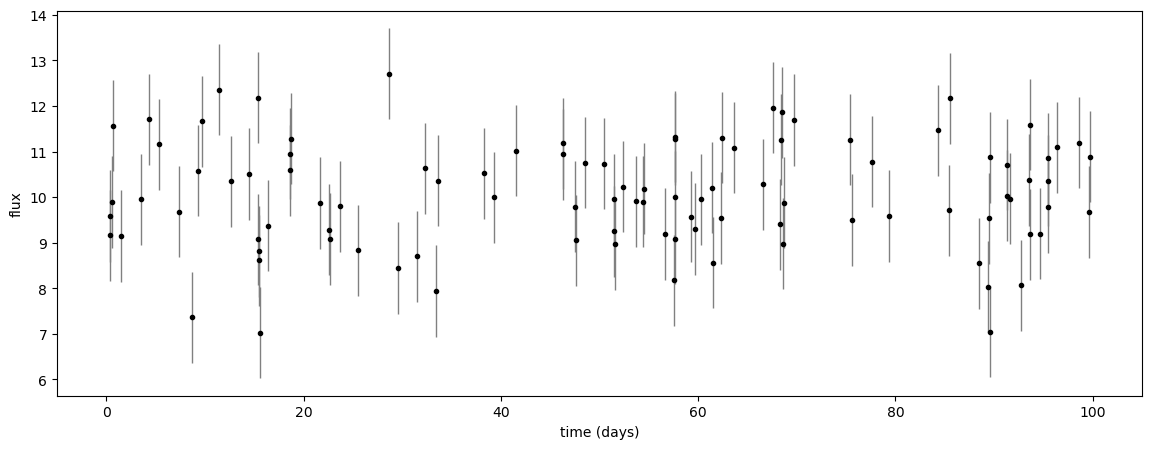

In [6]:
N = 100
P = 0.3 # period is 0.3 days 
sig = 1.0
A = 1.0
time, y, yObs, yErr = makeData(N, b0, sig, P, A)
# plot the results
plotLC(time, yObs, yErr)

## Detection: Is the Object Variable?

How do we detect if an object is variable? We show that it is inconsistent with being unvarying!

If the errors are known and Gaussian, we can simply compute $\chi^2$ for the data ***assuming the model where the object is constant***, and see how likely that $\chi^2$ is.

If we assume the object is **not** variable (i.e., $y(t) = y_0 = const.$), the $\chi^2$ will be equal to:

  * $\chi^2_{\rm dof}=\frac{1}{N} \sum_j \left(\frac{y_j - y_0}{\sigma}\right)^2$.

If this model is true, then:

  * $\chi^2_{\rm dof}$ has  expectation value of 1 and std dev  of $\sqrt\frac{2}{N}$

(where $N$ is the number of degrees of freedom, which can be approximated with the number of datapoints when that number is much larger than the number of parameters; see the lectures on Maximum Likelihood and discussion of $\chi^2$).

If there is variability, then:
- $\chi^2_{\rm dof}$ will be larger than 1. Is this discrepancy just luck of the draw, or an indication that the object is variable?
- We can assess that, as we know that $\chi^2_{dof}$ is drawn from a normal distribution (for large $N$). E.g., probability that $\chi^2_{\rm dof}>1 + 3 \sqrt{2/N}$  is about 1 in 1000 (i.e., $>3\sigma$ above 1)

Given a chosen acceptable false-positive rate (i.e., even without variability, 1 times in X we will observe a $\chi^2_{\rm dof}$ above the chosen threshold) then we can claim we detected variability.

This is the best that we can do under the assumption of the null hypothesis of no variability.  If instead we know the model (not limited to periodic variability), then we can perform a [**"matched filter"**](https://en.wikipedia.org/wiki/Matched_filter) analysis and improve upon this (i.e., we can positively identify lower-amplitude variability).

Imagine we have a sinusoidal variable signal

$$y(t) = y_0 + A \sin(\omega t)$$

that is measured with homoscedastic errors, $\sigma$. The variance of this signal is $V = \sigma^2 + A^2/2$, so we expect the $\chi^2_{\rm dof}$ for a model with no variability to be:

* $\chi^2_{\rm dof}=\frac{1}{N} \sum_j \left(\frac{y_j - y_0}{\sigma}\right)^2 \sim V/\sigma^2$.


If we choose $3 \sigma$ (1:1000 false positive rate) as the threshold, we find that the minimum detectable amplitude is:

$$A > \left( \frac{72}{N} \right)^\frac{1}{4} \sigma \approx 2.9 \sigma N^{-{1 \over 4}}$$

which follows from equating $V/\sigma^2=1 + 3 \sqrt{2/N}$, expanding $V$, and solving for $A$.

For $N=100$ data points, the minimum detectable amplitude is $A=0.92\sigma$

For $N=1000$, $A = 0.52\sigma$ 

That is, if we have enough data points, we can actually detect variability whose amplitude is smaller than the uncertainty in the measurements.

## Periodic signals ($\S$ 10.3)

Many systems have **periodic** signals.  This is especially true in astronomy (e.g., RR-Lyrae, Cepheids, eclipsing binaries).

What we want to be able to do is to detect variability and measure the period in the face of both noisy and incomplete data.

For example, the figure on the left is the kind of data that you *want* to have, whereas the figure on the right is the kind of data that you are more likely to have.

<img src="figures/rrlyrae-good.png" style="float: left; width: 40%; margin-right: 1%;"> <img src="figures/rrlyrae-bad.png" style="float: left; width: 40%; margin-right: 1%;">

For a periodic signal we have:

$$y(t+P)=y(t),$$ where $P$ is the period.

We can create a *phased light curve* that plots the data as function of phase:

$$\phi=\frac{t}{P} − {\rm int}\left(\frac{t}{P}\right),$$

where ${\rm int}(x)$ returns the integer part of $x$.

In [7]:
# given t and P: 
# phase = t / P - np.floor(t/P)

### A Single Sinusoid

Let's take the case where the data are drawn from a sinusoidal signal:

$$y(t)=A \sin(\omega t+\phi)+\epsilon$$

We wish to determine whether or not the data are indeed consistent with periodic variability and, if so, what is the period.

We can use trig identies to rewrite the model as

$$y(t)=a \sin(\omega t)+b \cos(\omega t),$$

where $A=(a^2+b^2)^{1/2}$ and $\phi=\tan^{−1}(b/a)$.

The model is now linear with respect to coefficients $a$ and $b$ (and nonlinear only with respect to frequency, $\omega$).  We now seek to determine the values of those parameters.


### The Likelihood and the Posterior

Assuming homoscedastic Gaussian errors the likelihood for this model becomes,

$$L\equiv p({t,y}|\omega,a,b,\sigma)=\prod^N_{j=1}\frac{1}{\sqrt{2π}\sigma} \exp \left(\frac{−[y_j− model_j)]^2}{2\sigma^2} \right). $$


which becomes
$$L\equiv p({t,y}|\omega,a,b,\sigma)=\prod^N_{j=1}\frac{1}{\sqrt{2π}\sigma} \exp \left(\frac{−[y_j−a \sin(\omega t_j)−b \cos(\omega t_j)]^2}{2\sigma^2} \right). $$

where $y_i$ is the measurement (e.g., the brightness of a star) taken at time $t_i$.

We adopt uniform priors on $a, b, \omega$, and $\sigma$. We make this choice of priors for computational convenience. They also make the result equivalent to maximum likelihood estimation.

Applying the Bayes theorem, and after some straighforward but tedious math, we find the posterior is equal to...

...:

$$p(\omega,a,b,\sigma|{t,y}) \propto \sigma^{−N} \exp \left(\frac{−NQ}{2\sigma^2} \right).$$

where

>$Q= V - {2\over N} \left[ a \, I(\omega) + b \, R(\omega) - a\, b\, M(\omega) - {1 \over 2} a^2 \, S(\omega) - {1 \over 2} b^2 \,C(\omega)\right]$

and

>$            V = {1\over N} \sum_{j=1}^N y_j^2$

>$       I(\omega) = \sum_{j=1}^N y_j   \sin(\omega t_j)$

>$ R(\omega) = \sum_{j=1}^N y_j  \cos(\omega t_j)$

>$      M(\omega) = \sum_{j=1}^N \sin(\omega t_j) \, \cos(\omega t_j)$

>$      S(\omega) = \sum_{j=1}^N \sin^2(\omega t_j)$

>$C(\omega) = \sum_{j=1}^N  \cos^2(\omega t_j)$

### Done (?)

At this point, we could simply apply the sampling machinery to estimate the posteriors for all the parameters.

However, we'd quickly run into two problems:
1. The posterior hyper-surfaces for these types of problems have many "hills and valleys"; they're not easy to sample from unless you approximately know the correct period. Often, the sampler may even get stuck sampling around a wrong solution.
1. Sampling is slow; in modern surveys we'll have **billions** of objects to assess. Running MCMC on each one is (still) computationally infeasible.

### Approximations: The posterior for many, randomly spaced, observations

Assumptions: If $N \gg 1$, and we have data that extends longer than the period, and hasn't been taken at special times, we have:

$S(\omega) \approx C(\omega) \approx N/2$ and $M(\omega) \ll N/2$ and

>$Q \approx V - {2\over N} \left[ a \, I(\omega) + b \, R(\omega)\right]  + {1 \over 2} (a^2 + b^2)$

If we marginalize over $a$ and $b$ (as we are interested in the period)

>$  p(\omega,\sigma|\{t,y\}) \propto  \sigma^{-(N-2)} \exp \left( { - N V \over 2 \sigma^2} + { P(\omega) \over \sigma^2}       \right)$

with $P(\omega) = {1 \over N} [ I^2(\omega) + R^2(\omega)]$

If we know the uncertainty $\sigma$ then 

>$   p(\omega|\{t,y\}, \sigma) \propto \exp \left( { P(\omega) \over \sigma^2} \right)$

and we now have the posterior for $\omega$!

The simplified posterior for $\omega$ comes out to be

$$ p(\omega|\{t,y\}, \sigma) \propto \exp \left(\frac{P(\omega)}{\sigma^2} \right),$$

where

$$P(\omega) = {1 \over N} [ I^2(\omega) + R^2(\omega)]$$

$$ I(\omega) = \sum_{j=1}^N y_j   \sin(\omega t_j), \; \; \; R(\omega) = \sum_{j=1}^N y_j  \cos(\omega t_j)$$

is the [periodogram](https://en.wikipedia.org/wiki/Periodogram).

### Periodogram

Periodogram $P(\omega)$ is a function of the frequency, but is frequently visualized as a plot of the "power" at each possible period (as illustrated below):

<img src="figures/periodogram.png">

Exponentiating this function would give us the (marginalized) PDF for $\omega$. Note the *numerous* peaks and valleys -- this is why blindly sampling it would be difficult!

### Periodogram: Relationship with $\chi^2$

Let's derive an expression for $\chi^2$ of this problem. It is given by:

$$\chi^2(\omega) \equiv {1 \over \sigma^2} \sum_{j=1}^N [y_j-y(t_j)]^2 =
  {1 \over \sigma^2} \sum_{j=1}^N [y_j- a_0\, \sin(\omega t_j) - b_0 \, \cos(\omega t_j)]^2,$$
  
which we can simplify (see the textbook) to:

$$\chi^2(\omega) =  \chi_0^2 \, \left[1 - {2 \over N \, V}  \, P(\omega) \right].$$

$P(\omega)$ is the periodogram as defined above. $V$ is the variance of the data. $\chi_0^2$ is the $\chi^2$ for a model with $y(t)=constant$:

$$  \chi_0^2 = {1 \over \sigma^2} \sum_{j=1}^N y_j^2 = {N \, V \over \sigma^2}$$

### The Lomb-Scargle periodogram

This is why we introduce the [Lomb-Scargle periodogram](https://en.wikipedia.org/wiki/Least-squares_spectral_analysis#The_Lomb.E2.80.93Scargle_periodogram) as:

$$P_{\rm LS}(\omega) = \frac{2}{N V} P(\omega),$$

Some properties of Lomb-Scargle and the periodogram:
- One can show that $0 \le P_{\rm LS}(\omega) \le 1$.
- The expected heights of the peaks in a periodogram don't depend on $\sigma$ but their width does.
- For $P_{\rm LS}(\omega_0)$, with no noise the peak approaches 1. As noise increases, $P_{\rm LS}(\omega_0)$ decreases and is ``buried'' in the background  noise.

### Example

Here is an example of a light curve of an object varying sinusoidally with a period that we'll need to find:

chi2 per degree of freedom: 12.867022323688458
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 83.91251957572248


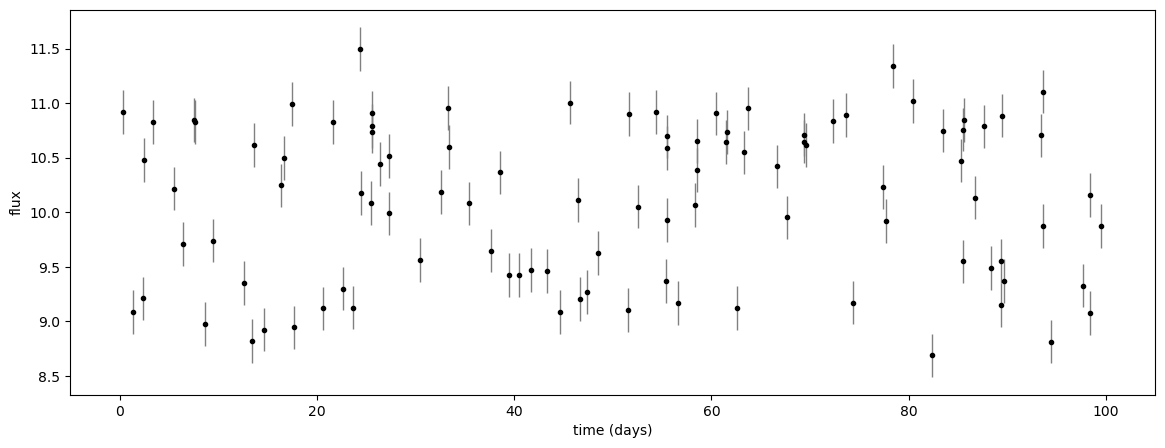

In [8]:
N = 100
P = 0.3  
sig = 0.2
A = 1.0
t, y, y_obs, dy = makeData(N, b0, sig, P, A)
# plot the results
plotLC(t, y_obs, dy)

Now let's find its period using astroML's [LS periodogram](http://www.astroml.org/gatspy/periodic/lomb_scargle.html) implementation:

In [9]:
# Similar to Figure 10.15 in the textbook
def plot_phased(t, y_obs, dy, P, ax = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14,7))

    phase = t / P - np.floor(t/P)
    ax.errorbar(phase, y_obs, dy, fmt='.k', lw=1, ecolor='gray')
    ax.set_xlabel('phase')
    ax.set_ylabel('flux')
    ax.set_xlim(-0.05, 1.05)
    
def getBestModelFit(t_fit, Pbest, t, y_obs, dy):
    
    # Design matrix
    omega_best = 2 * np.pi / Pbest
    X = np.vstack([
        np.sin(omega_best * t),
        np.cos(omega_best * t),
        np.ones_like(t)
        ]).T

    # Weighted least squares
    w = 1 / dy**2
    XTWX = X.T @ (w[:, None] * X)
    XTWy = X.T @ (w * y_obs)
    theta = np.linalg.solve(XTWX, XTWy)
    A_sin, A_cos, offset = theta
    
    # best-fit model
    y_fit = (
        A_sin * np.sin(omega_best * t_fit)
        + A_cos * np.cos(omega_best * t_fit)
        + offset
    )
    return y_fit

    
def plot_LS(t, y_obs, dy, P_fit, sig1, sig5, plotModel=True):
    #------------------------------------------------------------
    # Plot the results
    fig = plt.figure(figsize=(11, 11))
    fig.subplots_adjust(left=0.1, right=0.9, hspace=0.25)

    # First panel: the data
    ax = fig.add_subplot(311)
    ax.errorbar(t, y_obs, dy, fmt='.k', lw=1, ecolor='gray')
    ax.set_xlabel('time (days)')
    ax.set_ylabel('flux')
    ax.set_xlim(-5, 105);
    
    # Second panel: the phased light curve
    ax = fig.add_subplot(312)
    plot_phased(t, y_obs, dy, P_fit, ax=ax)
    if plotModel:
        tGrid = np.linspace(np.min(t), np.max(t), 100)
        bestFit = getBestModelFit(tGrid, P_fit, t, y_obs, dy)
        phaseGrid = tGrid / P_fit - np.floor(tGrid/P_fit)
        idx = np.argsort(phaseGrid)
        phaseGrid = phaseGrid[idx]
        bestFit = bestFit[idx]
        ax.plot(phaseGrid, bestFit, '--', c='red', lw=1)
            
            
    # Third panel: the periodogram & significance levels
    ax1 = fig.add_subplot(313, xscale='log')
    ax1.plot(period, PS, '-', c='black', lw=1, zorder=1)
    ax1.plot([period[0], period[-1]], [sig1, sig1], ':', c='black', label="99% significance level")
    ax1.plot([period[0], period[-1]], [sig5, sig5], '-.', c='black', label="95% significance level")
    ax1.legend()

    ax1.annotate("", (P_fit, 0.95), (P_fit, 1.10), ha='center', arrowprops=dict(arrowstyle='->'))

    ax1.set_xlim(period[0], period[-1])
    ax1.set_ylim(-0.05, 1.15)

    ax1.set_xlabel(r'period (days)')
    ax1.set_ylabel('power')

    # Twin axis: label BIC on the right side
    ax2 = ax1.twinx()
    ax2.set_ylim(tuple(lomb_scargle_BIC(ax1.get_ylim(), y_obs, dy)))
    ax2.set_ylabel(r'$\Delta BIC$')

    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax1.xaxis.set_minor_formatter(plt.FormatStrFormatter('%.1f'))
    ax1.xaxis.set_major_locator(plt.LogLocator(10))
    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3g'))

    plt.show()

In [10]:
from astroML.time_series import lomb_scargle, lomb_scargle_BIC, lomb_scargle_bootstrap

#------------------------------------------------------------
# Compute periodogram
period = 10 ** np.linspace(-1, 0, 10000)
omega = 2 * np.pi / period
PS = lomb_scargle(t, y_obs, dy, omega, generalized=True)

# find the highest peak
P_fit = period[PS.argmax()]

#------------------------------------------------------------
# Get significance via bootstrap
D = lomb_scargle_bootstrap(t, y_obs, dy, omega, generalized=True,
                           N_bootstraps=500, random_state=0)
sig1, sig5 = np.percentile(D, [99, 95])

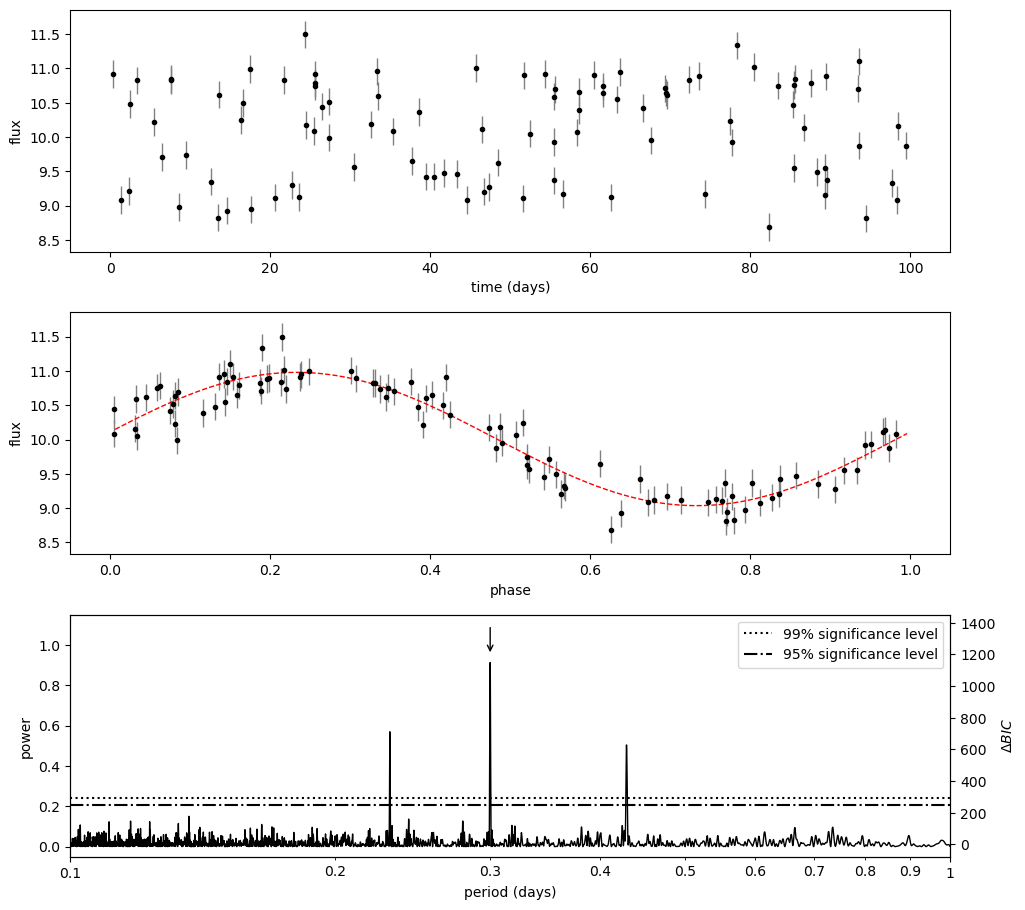

Location of highest periodogram peak, P_fit = 0.300 days


In [11]:
plot_LS(t, y_obs, dy, P_fit, sig1, sig5)
print(f"Location of highest periodogram peak, P_fit = {P_fit:.3f} days")

## Wasn't that impressive!? 

### Let's try again with larger measurement noise (compared to variability amplitude):  sigma = Amplitude
### With N=100, we can expect to barely detect periodicity

chi2 per degree of freedom: 1.2818987817737804
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 1.9933254020046682


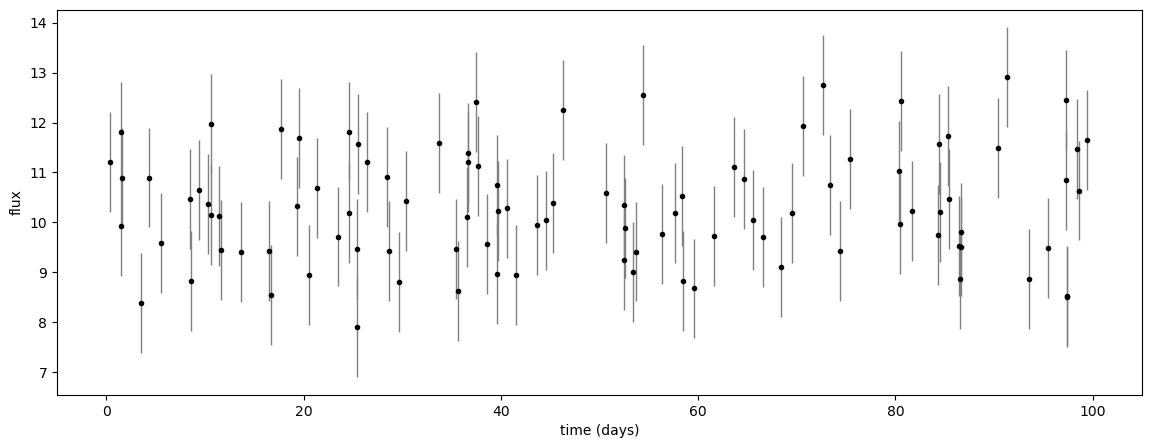

In [12]:
N = 100
P = 0.3  
sig = 1.0
A = 1.0
tdata, y, y_obs, dy = makeData(N, b0, sig, P, A)
# plot the results
plotLC(tdata, y_obs, dy)

In [13]:
#------------------------------------------------------------
# Compute periodogram
period = 10 ** np.linspace(-1, 0, 10000)
omega = 2 * np.pi / period
PS = lomb_scargle(tdata, y_obs, dy, omega, generalized=True)

# find the highest peak
P_fit = period[PS.argmax()]

#------------------------------------------------------------
# Get significance via bootstrap
D = lomb_scargle_bootstrap(tdata, y_obs, dy, omega, generalized=True,
                           N_bootstraps=500, random_state=0)
sig1, sig5 = np.percentile(D, [99, 95])

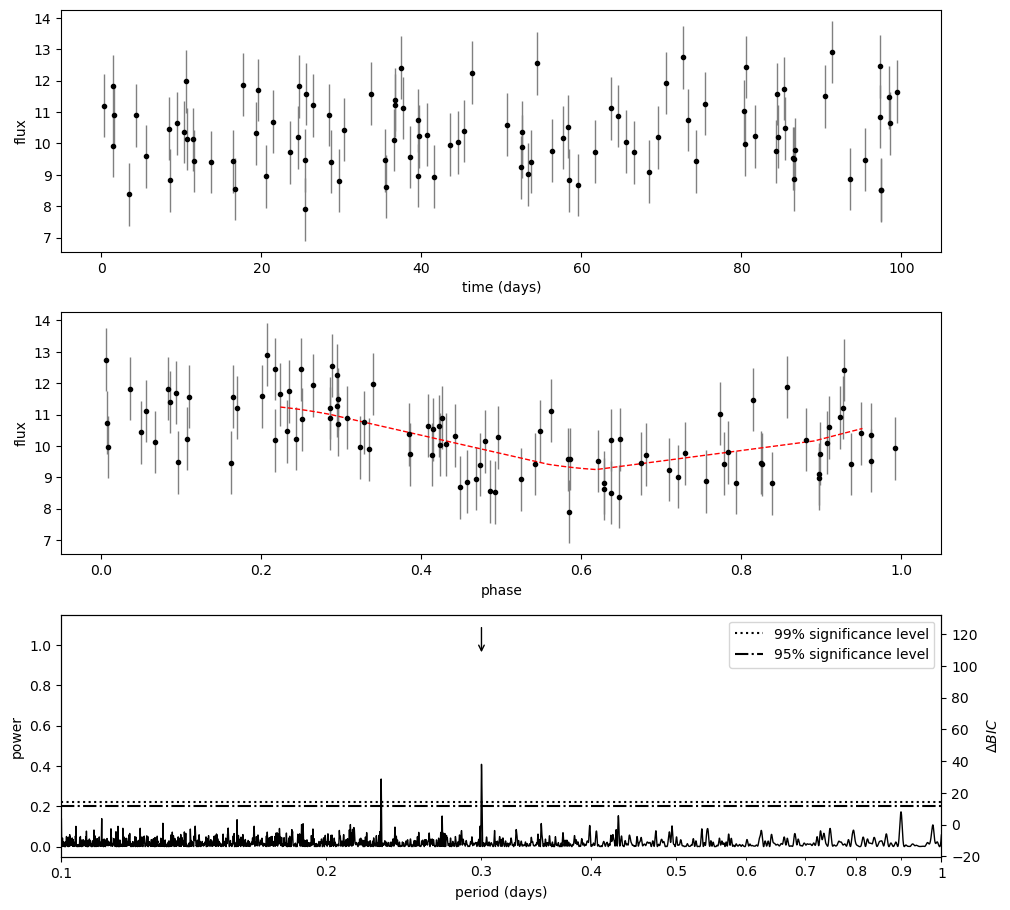

Location of highest periodogram peak, P_fit = 0.300 days


In [14]:
plot_LS(tdata, y_obs, dy, P_fit, sig1, sig5)
print(f"Location of highest periodogram peak, P_fit = {P_fit:.3f} days")

## now let's repeat the case with sigma = Amplitude, 
## but use N=1000 instead of N=100 and so on...

chi2 per degree of freedom: 1.4716341818619036
expected scatter in chi2dof: 0.044721359549995794
observed chi2dof departs from 1 by this many sigmas: 10.546060911557149


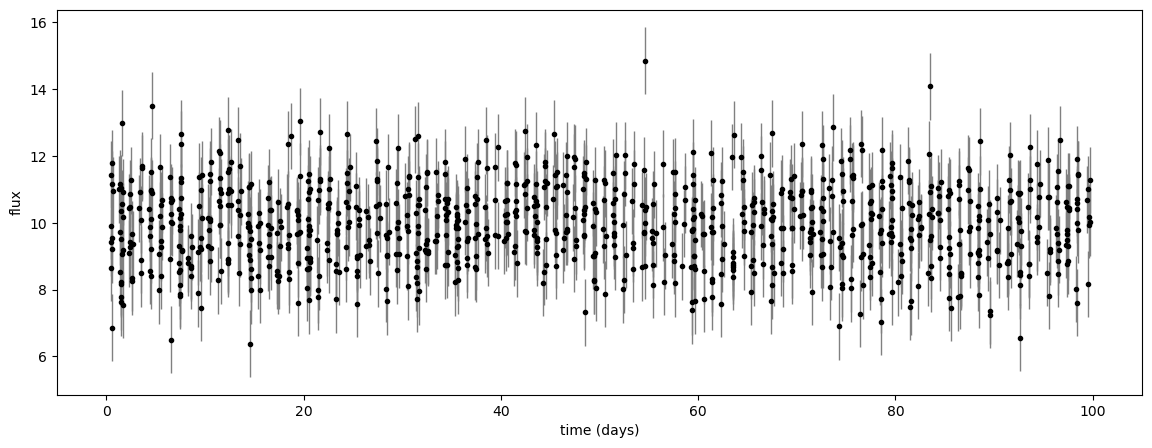

In [15]:
N = 1000
P = 0.3  
sig = 1.0
A = 1.0
tdata, y, y_obs, dy = makeData(N, b0, sig, P, A)
# plot the results
plotLC(tdata, y_obs, dy)

In [16]:
#------------------------------------------------------------
# Compute periodogram
period = 10 ** np.linspace(-1, 0, 10000)
omega = 2 * np.pi / period
PS = lomb_scargle(tdata, y_obs, dy, omega, generalized=True)

# find the highest peak
P_fit = period[PS.argmax()]

#------------------------------------------------------------
# Get significance via bootstrap
D = lomb_scargle_bootstrap(tdata, y_obs, dy, omega, generalized=True,
                           N_bootstraps=500, random_state=0)
sig1, sig5 = np.percentile(D, [99, 95])

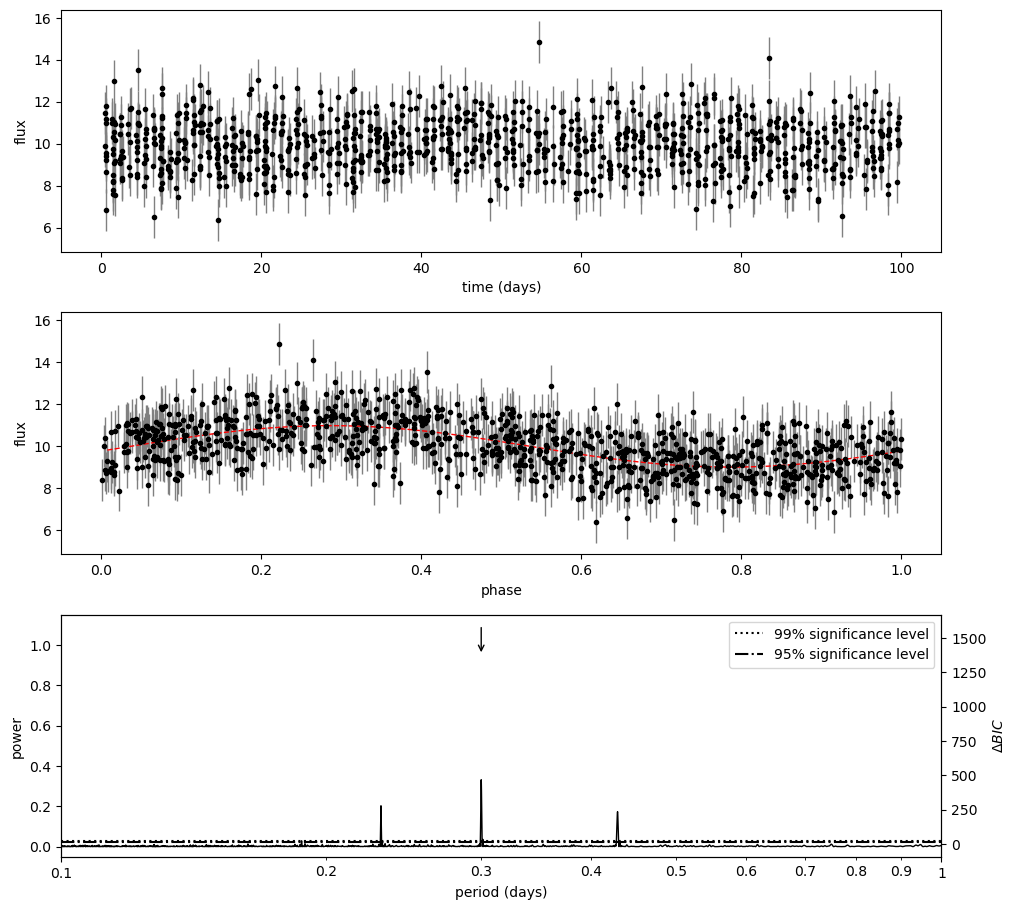

Location of highest periodogram peak, P_fit = 0.300 days


In [17]:
plot_LS(tdata, y_obs, dy, P_fit, sig1, sig5)
print(f"Location of highest periodogram peak, P_fit = {P_fit:.3f} days")

In [18]:
def doAll(N, sig, P, A):
    # generate data 
    b0 = 10.0 
    tdata, y, y_obs, dy = makeData(N, b0, sig, P, A)
    
    # Compute periodogram
    period = 10 ** np.linspace(-1, 0, 10000)
    omega = 2 * np.pi / period
    print('going to compute the Lomb-Scargle periodogram, be patient...')
    PS = lomb_scargle(tdata, y_obs, dy, omega, generalized=True)

    # find the highest peak
    P_fit = period[PS.argmax()]

    # Get significance via bootstrap
    D = lomb_scargle_bootstrap(tdata, y_obs, dy, omega, generalized=True,
                           N_bootstraps=500, random_state=0)
    sig1, sig5 = np.percentile(D, [99, 95])
    # plot
    plot_LS(tdata, y_obs, dy, P_fit, sig1, sig5)

chi2 per degree of freedom: 12.016551699306158
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 77.89878411871568
going to compute the Lomb-Scargle periodogram, be patient...


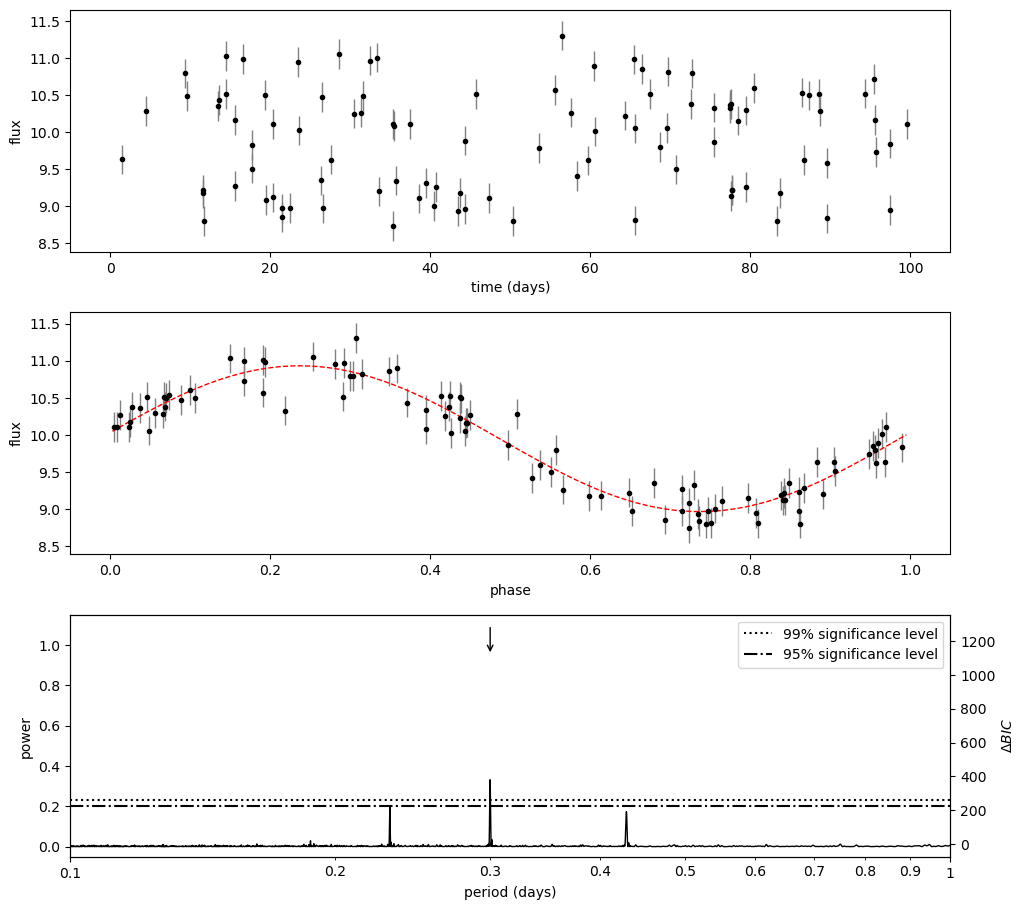

In [19]:
doAll(N=100, sig=0.2, P=0.3, A=1.0)

chi2 per degree of freedom: 13.287909377784764
expected scatter in chi2dof: 0.2581988897471611
observed chi2dof departs from 1 by this many sigmas: 47.590868379866336
going to compute the Lomb-Scargle periodogram, be patient...


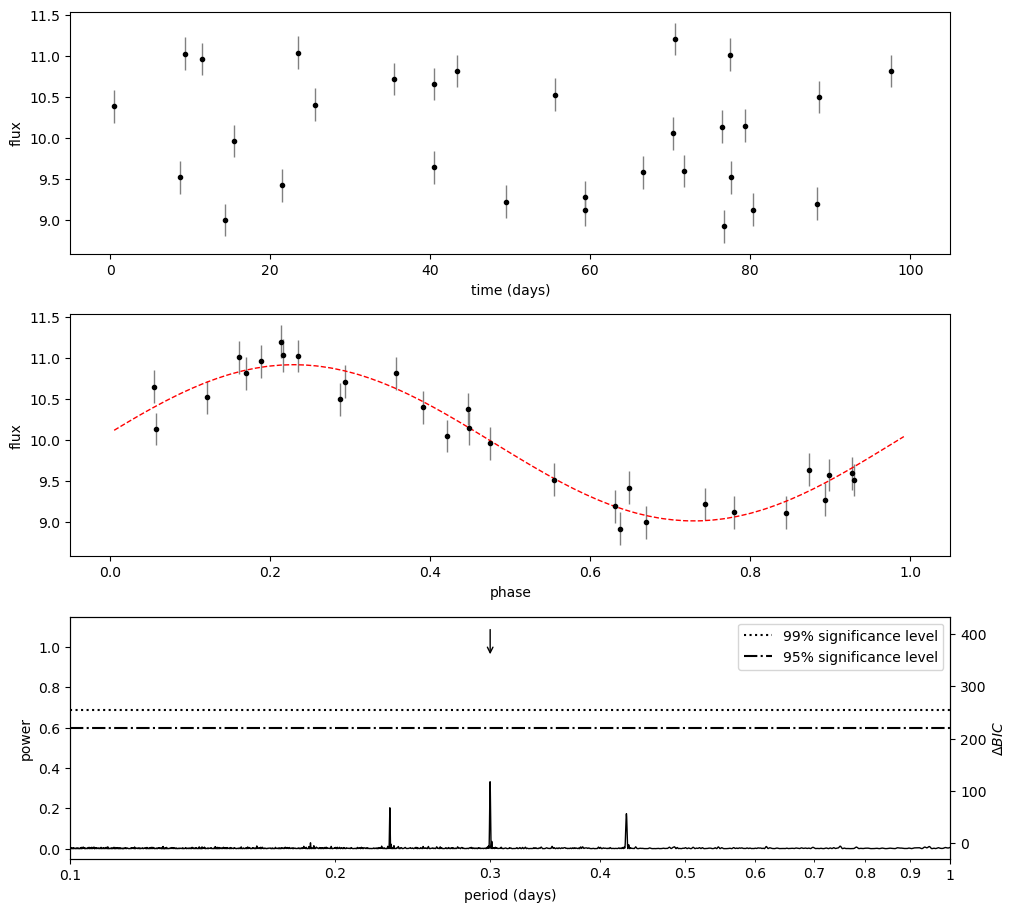

In [20]:
doAll(N=30, sig=0.2, P=0.3, A=1.0)

chi2 per degree of freedom: 3.0062530295501277
expected scatter in chi2dof: 0.2581988897471611
observed chi2dof departs from 1 by this many sigmas: 7.770184571725822
going to compute the Lomb-Scargle periodogram, be patient...


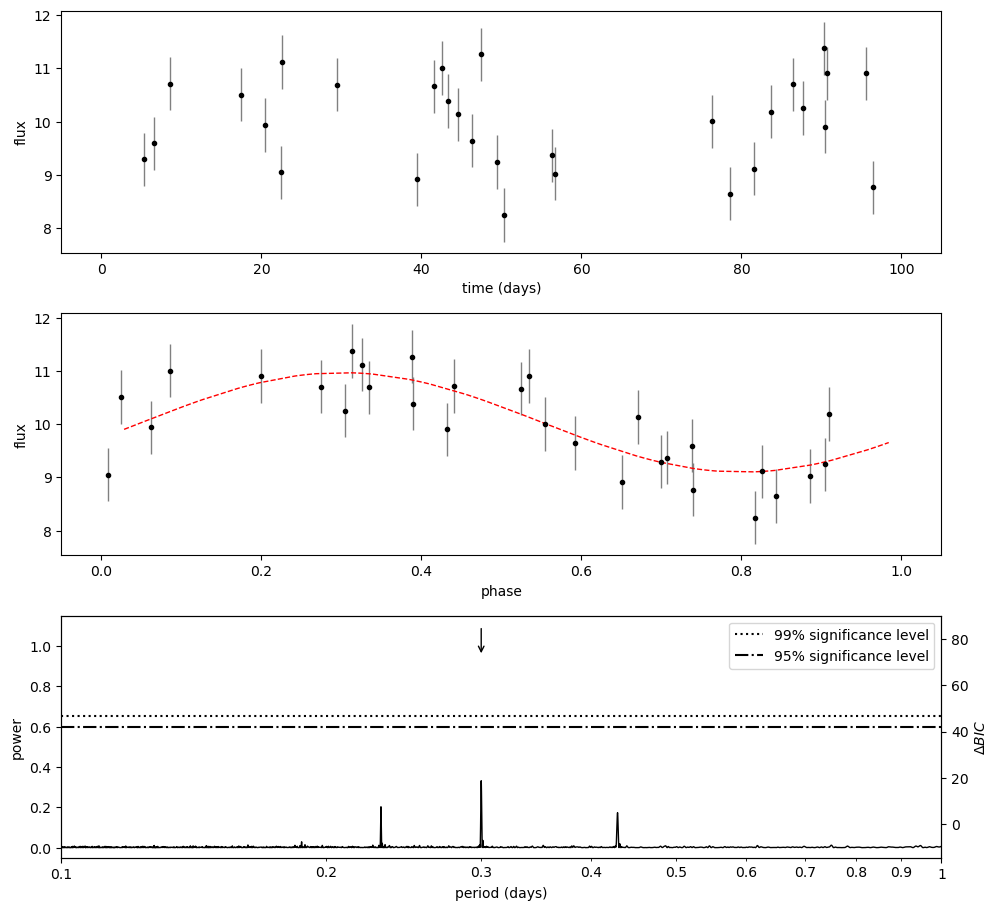

In [21]:
doAll(N=30, sig=0.5, P=0.3, A=1.0)

chi2 per degree of freedom: 1.4242124105178993
expected scatter in chi2dof: 0.2581988897471611
observed chi2dof departs from 1 by this many sigmas: 1.642967601190328
going to compute the Lomb-Scargle periodogram, be patient...


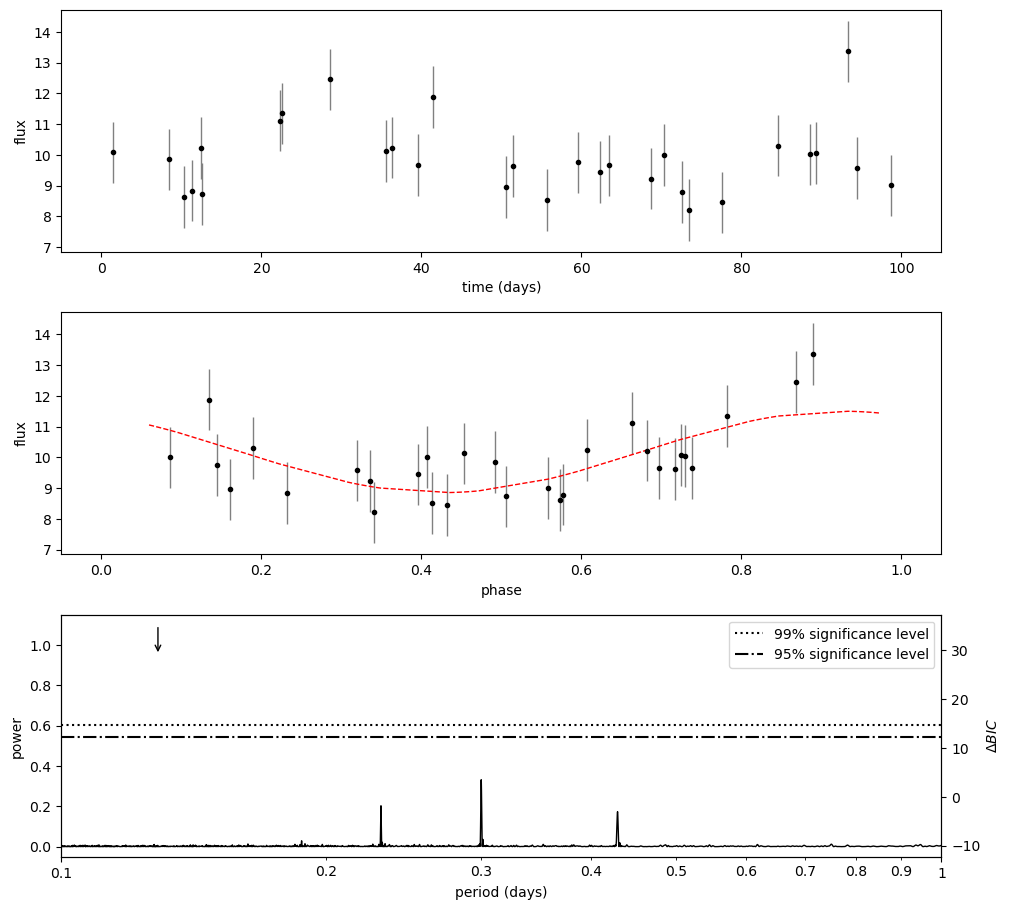

In [22]:
doAll(N=30, sig=1.0, P=0.3, A=1.0)

chi2 per degree of freedom: 1.5751814202377534
expected scatter in chi2dof: 0.08164965809277261
observed chi2dof departs from 1 by this many sigmas: 7.044504945559188
going to compute the Lomb-Scargle periodogram, be patient...


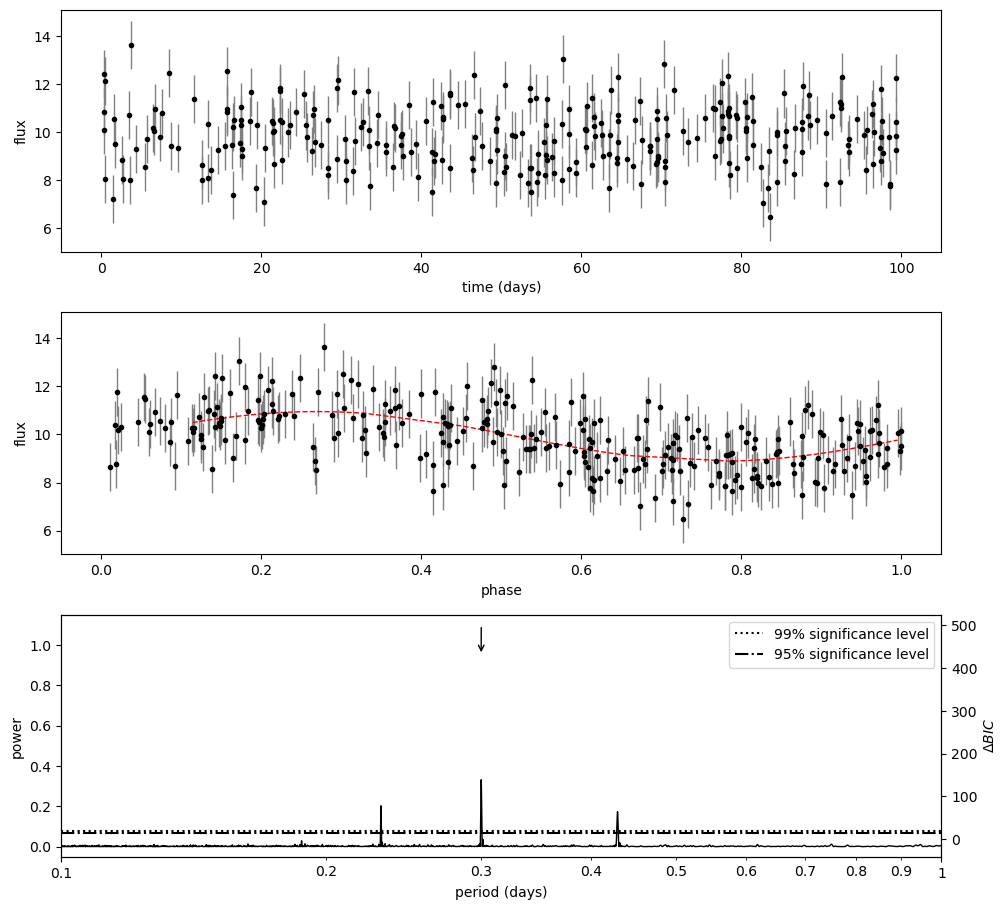

In [23]:
doAll(N=300, sig=1.0, P=0.3, A=1.0)

chi2 per degree of freedom: 1.2443068115730185
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 1.7275100315334548
going to compute the Lomb-Scargle periodogram, be patient...


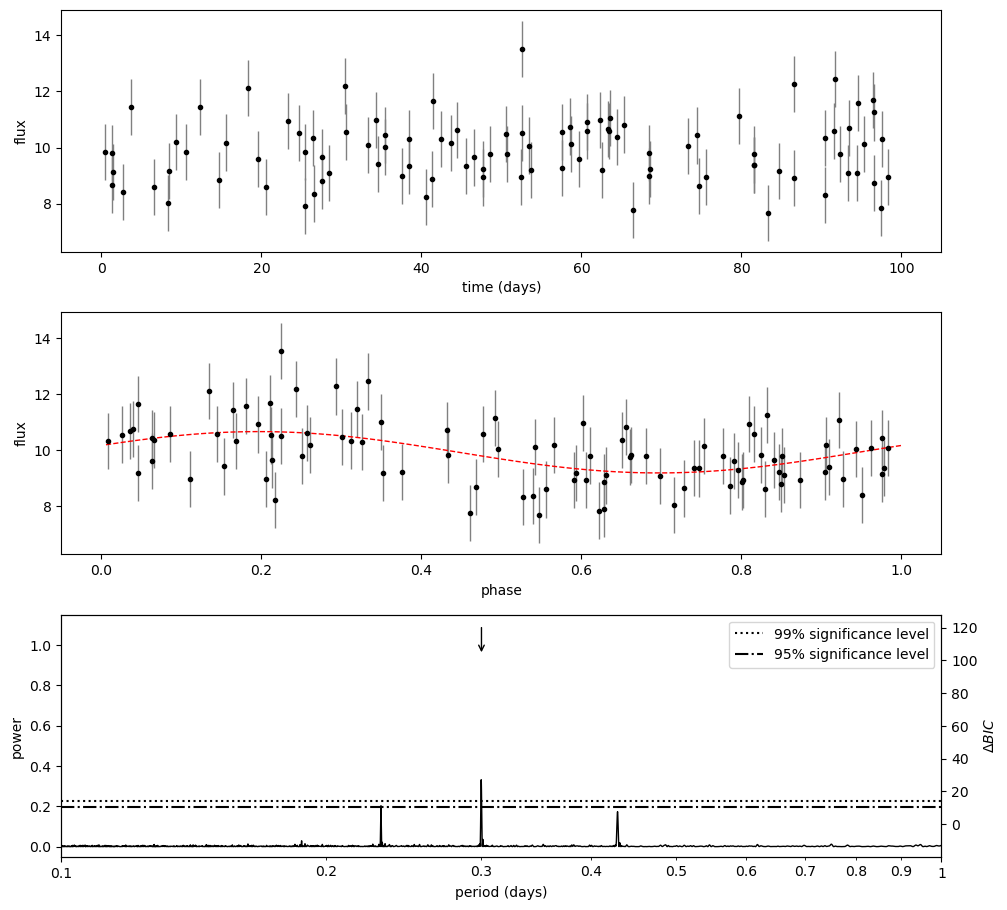

In [24]:
doAll(N=100, sig=1.0, P=0.3, A=0.92)

chi2 per degree of freedom: 54.706982678625714
expected scatter in chi2dof: 0.1414213562373095
observed chi2dof departs from 1 by this many sigmas: 379.7657164912469
going to compute the Lomb-Scargle periodogram, be patient...


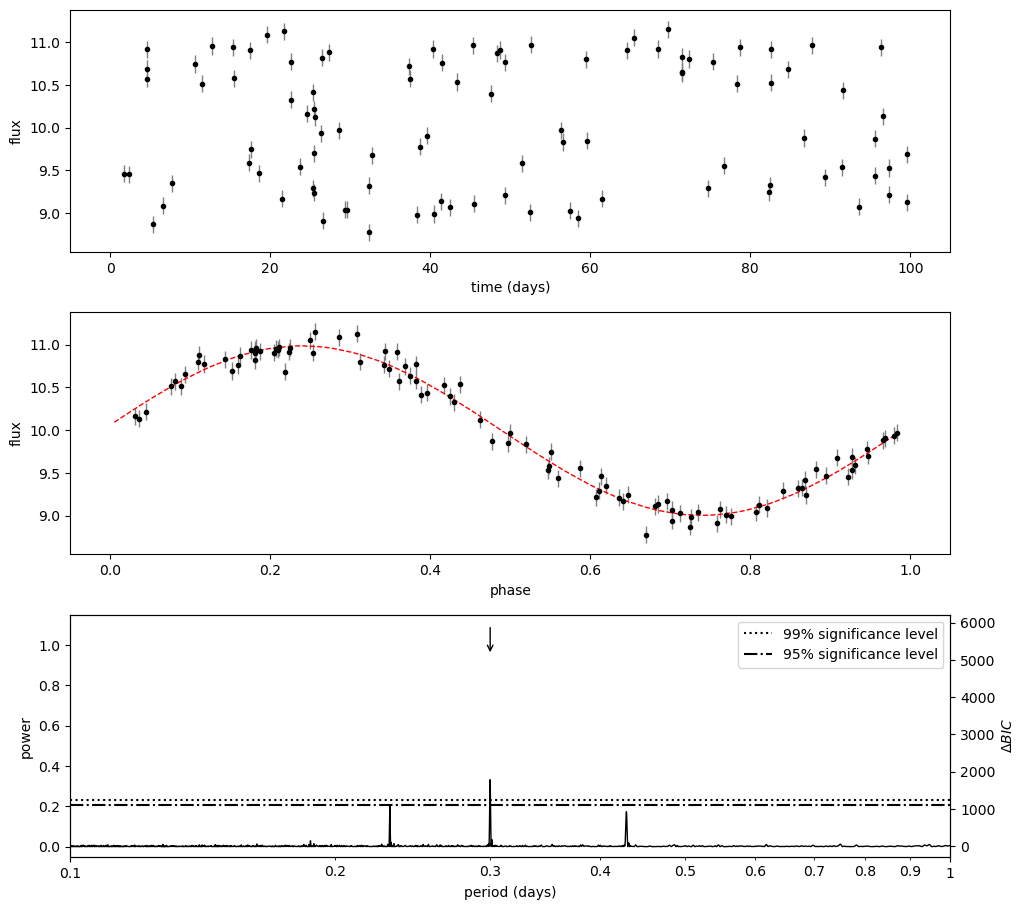

In [25]:
doAll(N=100, sig=0.1, P=0.3, A=1.0)

chi2 per degree of freedom: 49.74748874693491
expected scatter in chi2dof: 0.044721359549995794
observed chi2dof departs from 1 by this many sigmas: 1090.026985705525
going to compute the Lomb-Scargle periodogram, be patient...


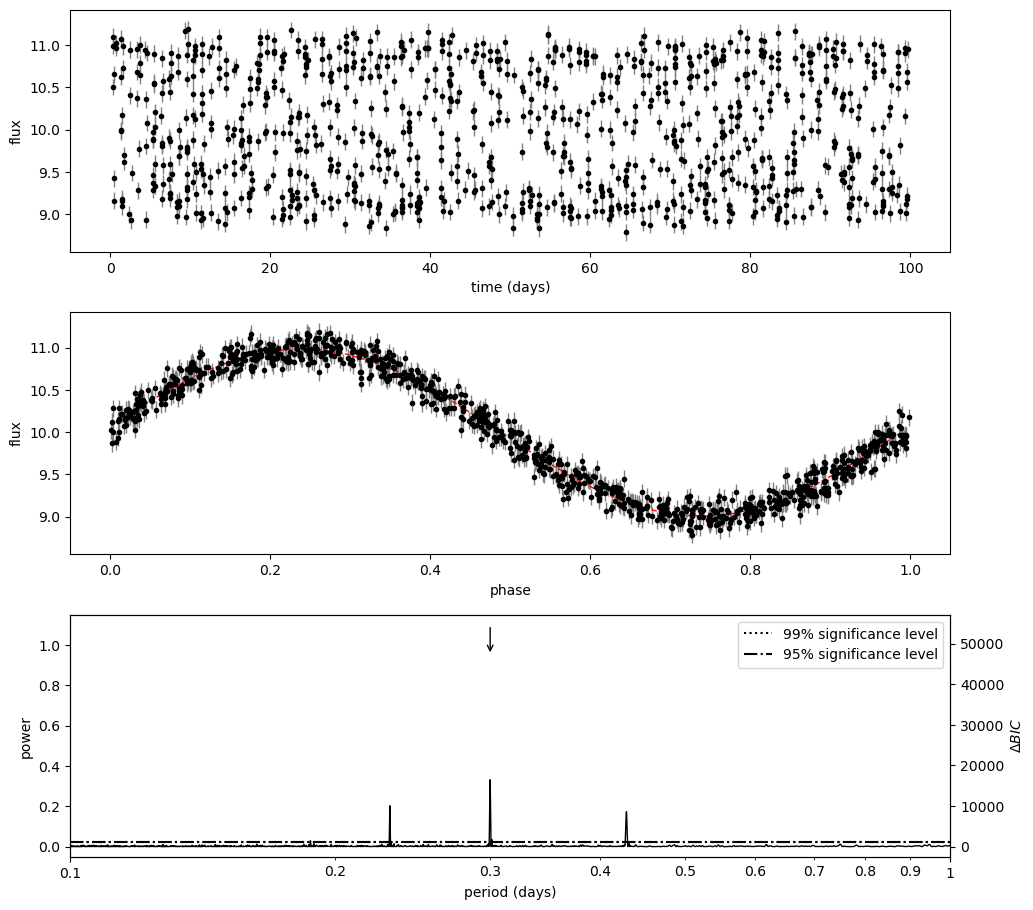

In [26]:
doAll(N=1000, sig=0.1, P=0.3, A=1.0)

## False Alarm Probability

The two horizontal dashed lines in the periodogram above correspond to FAPs of
0.01 and 0.001. 

FAP is **not** the probability that we really found the correct period of a variable object.

Rather, it is probability that we would get the strongest periodogram peak that high
from a time series that was pure noise. 

To get the model probability ratio of variable star vs. noise (constant flux), we need to take into
account their prior probabilities (Bayes!): 

$$ {p(Var\,|\,Peak) \over p(Const\,|\,Peak)} = {p(Peak\,|\, Var) \over p(Peak\,|\,Const)} \, {p(Var) \over p(Const)}.
$$

Here FAP corresponds to $p(Peak\,|\,Const)$, and with $p(Peak\,|\, Var) \sim 1$, we have

$$ {p(Var\,|\,Peak) \over p(Const\,|\,Peak)} = {1 \over FAP} \, {p(Var) \over p(Const)}. $$

The ratio of priors [p(Var)/p(Const)] is the fraction of variable stars in the studied population. 
It is typically a few percent (of the order 0.01) - therefore, in order to have a reliable detection of
period (say, LHS $>$10), FAP should be at least as small as 0.001. 

In [27]:
plt.style.use('ggplot')

from astropy.timeseries import LombScargle

rng = np.random.RandomState(42)

def getSimLC():
    N = 100
    t = 5 * rng.rand(N)
    t -= 0.5 * (t % 1)  # create alias-inducing structure in the window function
    dy = 0.5 * (1 + rng.rand(N))
    y = dy * rng.randn(N)
    return t, y, dy    
      
        
def testLS(t, y, dy):

    ls = LombScargle(t, y, dy, normalization='standard')
    zmax = 0.23
    z = np.linspace(0.001, zmax, 10000)
    
    def false_alarm(method):
        return ls.false_alarm_probability(z, method=method, maximum_frequency=5)

    fa_boot = ls.false_alarm_probability(z, method='bootstrap',
                                         maximum_frequency=5,
                                         method_kwds=dict(random_seed=42))

    fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.plot(z, false_alarm('naive'), label='naive estimate')
    ax.plot(z, false_alarm('baluev'), label='Baluev estimate')
    ax.plot(z, false_alarm('davies'), ':k', label='Davies bound')
    ax.plot(z, fa_boot, '-k', label='bootstrap estimate')

    ax.legend(loc='lower left')
    ax.set(yscale='log',
           title='False Alarm Estimates (N=100)',
           xlim=(0, zmax), ylim=(0.001, 1.5),
           xlabel='Value of Highest Periodogram Peak',
           ylabel='False Alarm Probability');

    return 

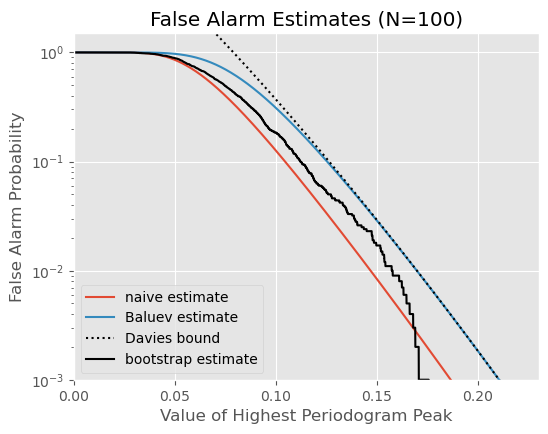

In [28]:
t, y, dy = getSimLC()
testLS(t, y, dy)

In [29]:
def simulated_data(N, rseed=2, period=0.41, phase=0.0):
        """Simulate data based from a pre-computed empirical fit"""

        # coefficients from a 5-term Fourier fit to SDSS object 1019544
        coeffs = [-0.0191, 0.1375, -0.1968, 0.0959, 0.075,
                  -0.0686, 0.0307, -0.0045, -0.0421, 0.0216, 0.0041]

        rand = np.random.RandomState(rseed)
        t = phase + np.arange(N, dtype=float)
        t += 0.1 * rand.randn(N)
        dmag = 0.01 + 0.03 * rand.rand(N)

        omega = 2 * np.pi / period
        n = np.arange(1 + len(coeffs) // 2)[:, None]

        mag = (15 + dmag * rand.randn(N)
               + np.dot(coeffs[::2], np.cos(n * omega * t)) +
               + np.dot(coeffs[1::2], np.sin(n[1:] * omega * t)))

        return t, mag, dmag

def plotLS():
    # generate data and compute the periodogram
    t, mag, dmag = simulated_data(50)
    ls = LombScargle(t, mag, dmag, normalization='standard')
    freq, PLS = ls.autopower(minimum_frequency=1 / 1.2,
                             maximum_frequency=1 / 0.2)
    best_freq = freq[np.argmax(PLS)]
    phase = (t * best_freq) % 1

    # compute the best-fit model
    phase_fit = np.linspace(0, 1)
    mag_fit = ls.model(t=phase_fit / best_freq,
                       frequency=best_freq)

    # set up the figure & axes for plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Lomb-Scargle Periodogram (period=0.41 days)')
    fig.subplots_adjust(bottom=0.12, left=0.07, right=0.95)
    inset = fig.add_axes([0.78, 0.56, 0.15, 0.3])

    # plot the raw data
    ax[0].errorbar(t, mag, dmag, fmt='ok', elinewidth=1.5, capsize=0)
    ax[0].invert_yaxis()
    ax[0].set(xlim=(0, 50),
              xlabel='Observation time (days)',
              ylabel='Observed Magnitude')

    # plot the periodogram
    ax[1].plot(1. / freq, PLS)
    ax[1].set(xlabel='period (days)',
              ylabel='Lomb-Scargle Power',
              xlim=(0.2, 1.2),
              ylim=(0, 1));

    # plot the false-alarm levels
    z_false = ls.false_alarm_level(0.01, maximum_frequency=1 / 0.2,
                                   method='baluev')
    ax[1].axhline(z_false, linestyle='dotted', color='black')
    z_false = ls.false_alarm_level(0.001, maximum_frequency=1 / 0.2,
                                   method='baluev')
    ax[1].axhline(z_false, linestyle='dotted', color='blue')
    

    # plot the phased data & model in the inset
    inset.errorbar(phase, mag, dmag, fmt='.k', capsize=0)
    inset.plot(phase_fit, mag_fit)
    inset.invert_yaxis()
    inset.set_xlabel('phase')
    inset.set_ylabel('mag')

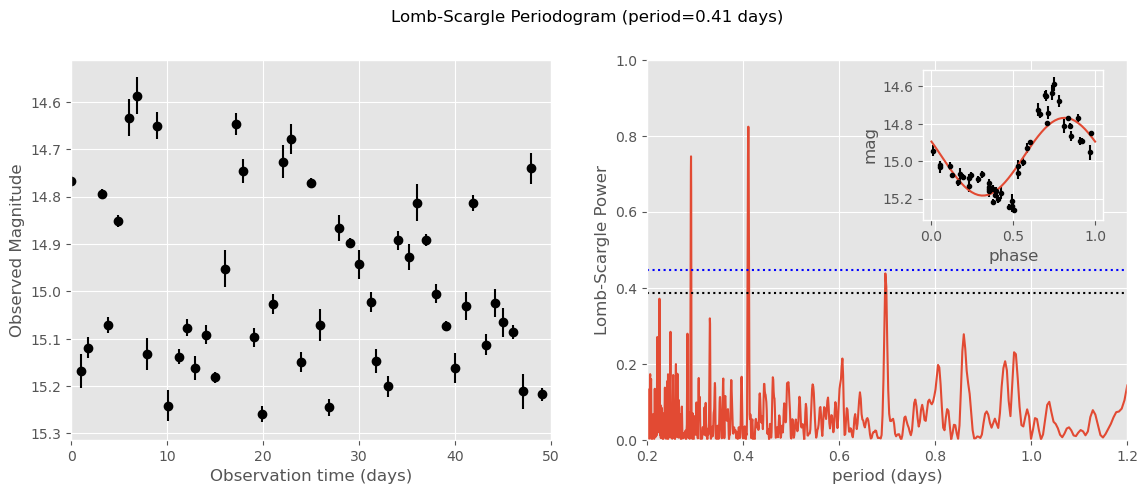

In [30]:
plotLS()

**False Alarm Probability:**
The two horizontal dashed lines in the periodogram above correspond to FAPs of 0.01 and 0.001.

These FAPs were computed using a bootstrap method. Lomb-Scargle implementation in astropy includes several other methods (much faster but less accurate), as shown above.

**NOTE:** the FAP in a given periodogram is a function of time sampling and measurement errors - it needs to be (re)computed every time you produce a new periodogram!

### Aliasing

But why did we have 3 peaks above the line FAP=0.001???

The two most common problems are sampling aliases (e.g. observations spaced by roughly 1 day) and inability of a single sinusoid to fit the shape of light curve (always check if there is another significant peak at twice the best-fit period).

For details see Section 7.2 in "Understanding the Lomb-Scargle Periodogram" by Jake VanderPlas (2017, arXiv:1703.09824).
 

### Examples of periodic variable stars from LINEAR


<img src="figures/LINEARexample.png" style="float: right; width: 100%; margin-right: 1%;">



### Example of a bad period (with a single sinusoid) 


<img src="figures/LINEARbadfit.png" style="float: right; width: 100%; margin-right: 1%;">



## Non-sinusoidal signals

We've derived and discussed LS periodogram by looking at sinusoidal variation; real objects' light curve shapes are frequently more complex than sinusoids. Often, we can model more complex light curves with more harmonic terms: 

$$\begin{eqnarray}
  &y(t|\omega,\theta) =
  \theta_0 + \sum_{n=1}^{N_{terms}} \left[\theta_{2n - 1}\sin(n\omega t) + \theta_{2n}\cos(n\omega t)\right].&
\end{eqnarray}$$




Even so, **LS remains an efficient technique to find the period of variability**, as long as the object varies with a well-defined period. The highest peak (usually) gives the variability period.


The process is always:
  1. Obtain the data, ensure they satisfy the assumptions under which LS has been derived (N $\gtrsim$ 20 data points, randomly distributed, span many periods)
  1. Compute the LS periodogram
  1. Find the highest peak
  1. Fold (phase) the light curve to study its shape, amplitude, etc.


# Generalizations

### Generalized Lomb-Scargle

The Lomb-Scargle periodogram is a fit to a model:

$$y(t)=a \sin(\omega t)+b \cos(\omega t),$$

whose mean is zero. In reality, the observed variability is typically around some (mean) value, not zero. We deal with this by subtracting the mean of the sample $\overline{y}$ from the data before performing the periodogram analysis.

That only works if $\overline{y}$ is a good estimator of the mean of the distribution, $y(t)$ -- if the data is equally sampled at all phases. However, in practice, the data may not equally sample all of the phases.

For example, consider the case of a star that has a period of one day and the fact that a single optical telescope only takes data at night. In that case you we might get something like the top panel below:

![Ivezic, Figure 10.16](http://www.astroml.org/_images/fig_LS_sg_comparison_3.png)

The standard LS approach misses the true period at $\omega \approx 20.95$.

The "generalized" Lomb-Scargle approach (also implemented in astroML) can help with this as can be seen in the bottom panel above. It fits the model with non-zero mean:

$$y(t)=a \sin(\omega t)+b \cos(\omega t) + C$$

See also [Figure 10.16](http://www.astroml.org/book_figures/chapter10/fig_LS_sg_comparison.html) in the textbook.

## Multiband LS periodograms

One of the issues that we are going to be dealing with in astronomy over the next decade as the LSST project comes online is the problem of sparsely-sampled light curves, but with multiple light curves for each object -- one for each "bandpass" as seen below:

<img src="figures/multibandLS.png" style="float: right; width: 100%; margin-right: 1%;">



**None of single-band light curves has enough information to constrain the period even with LS, but the multi-band method finds the correct period with high significance!**

The generalized LS was an extension to account for the mean value. We can build on this to account for multiple modes of variation and multiple bands by fitting for a global period, global mean, and a per-band offsets.

$$\begin{eqnarray}
  &y_k(t|\omega,\theta) =
  \theta_0 + \sum_{n=1}^{N_{base}} \left[\theta_{2n - 1}\sin(n\omega t) + \theta_{2n}\cos(n\omega t)\right] +&\nonumber
  &\theta^{(k)}_0 + \sum_{n=1}^{N_{band}} \left[\theta^{(k)}_{2n - 1}\sin(n\omega t) + \theta^{(k)}_{2n}\cos(n\omega t)\right].&
\end{eqnarray}$$

The period and phase are shared across all bands. **If we simply added power spectra from each band, we would not end up with the same phase across bands.**

The total number of parameters for $K$ filters is then $M_K = (2N_{base} + 1) + K(2N_{band} + 1)$. 

The important feature of this model is that _all bands_ share the same base parameters, $\theta$, while their offsets $\theta^{(k)}$ are determined individually.

<img src="figures/multibandLS-LSST.png" style="float: right; width: 100%; margin-right: 1%;">


In [31]:
from gatspy.datasets import fetch_rrlyrae

# Patch for changed URL
import gatspy.datasets.rrlyrae
gatspy.datasets.rrlyrae.SESAR_RRLYRAE_URL = 'https://github.com/astroML/astroML-data/raw/master/datasets/S82_RRLyr/'

rrlyrae = fetch_rrlyrae()
lcid = rrlyrae.ids[0]

t, y, dy, filts = rrlyrae.get_lightcurve(lcid)
period = rrlyrae.get_metadata(lcid)['P']
print('precomputed (known) period:', period)

def plot_data(lcid):
    t, y, dy, filts = rrlyrae.get_lightcurve(lcid)
    
    tfit = np.linspace(0, period, 1000)
    for filt in 'ugriz':
        mask = (filts == filt)
        eb = plt.errorbar(t[mask] % period, y[mask], dy[mask], fmt='.', label=filt)
    plt.gca().invert_yaxis()
    plt.legend(ncol=3, loc='upper left')

precomputed (known) period: 0.6143183


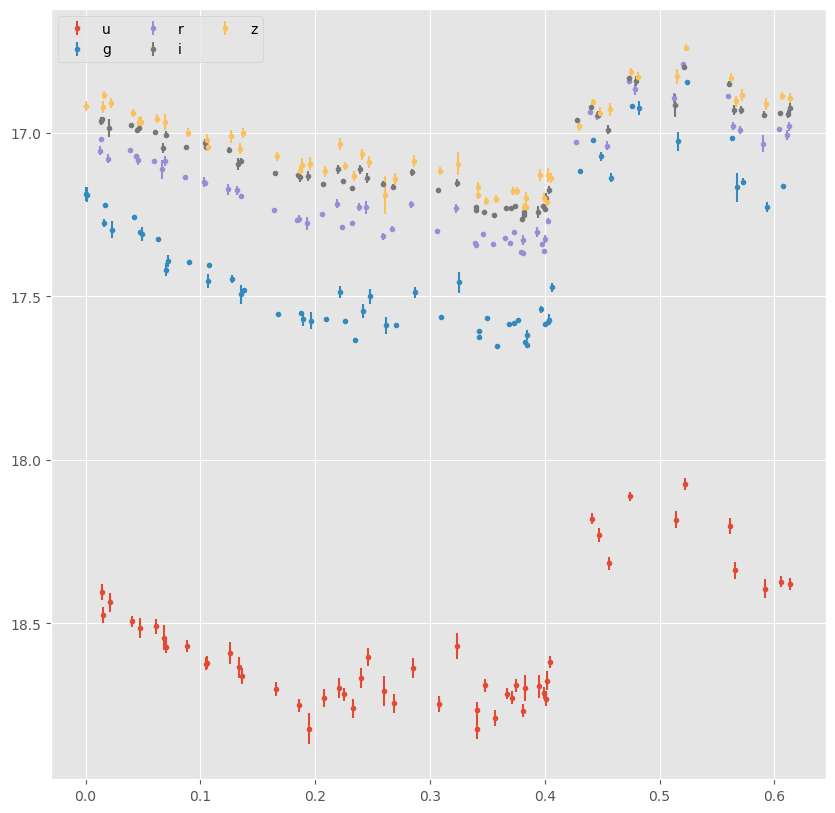

In [32]:
fig = plt.figure(figsize=(10,10))
plot_data(lcid)

In [33]:
from gatspy.periodic import LombScargleMultiband


def plot_model(model, lcid):
    t, y, dy, filts = rrlyrae.get_lightcurve(lcid)
    model.fit(t, y, dy, filts)
    periods = np.linspace(period - 0.1, period + 0.1, 2000)
    power = model.periodogram(periods)
    best_period = periods[np.argmax(power)]
    print('best LombScargleMultiband period:', best_period)

    tfit = np.linspace(0, period, 1000)
    for filt in 'ugriz':
        mask = (filts == filt)
        eb = plt.errorbar(t[mask] % period, y[mask], dy[mask], fmt='.', label=filt)
        yfit = model.predict(tfit, filt, period=best_period)
        plt.plot(tfit, yfit, color=eb[0].get_color())
    plt.gca().invert_yaxis()
    plt.legend(ncol=3, loc='upper left')

Below we show the multi-band light curves of an RR Lyrae star as an example; the period is correctly identified (and the light curve is folded nicely).

best LombScargleMultiband period: 0.6143683


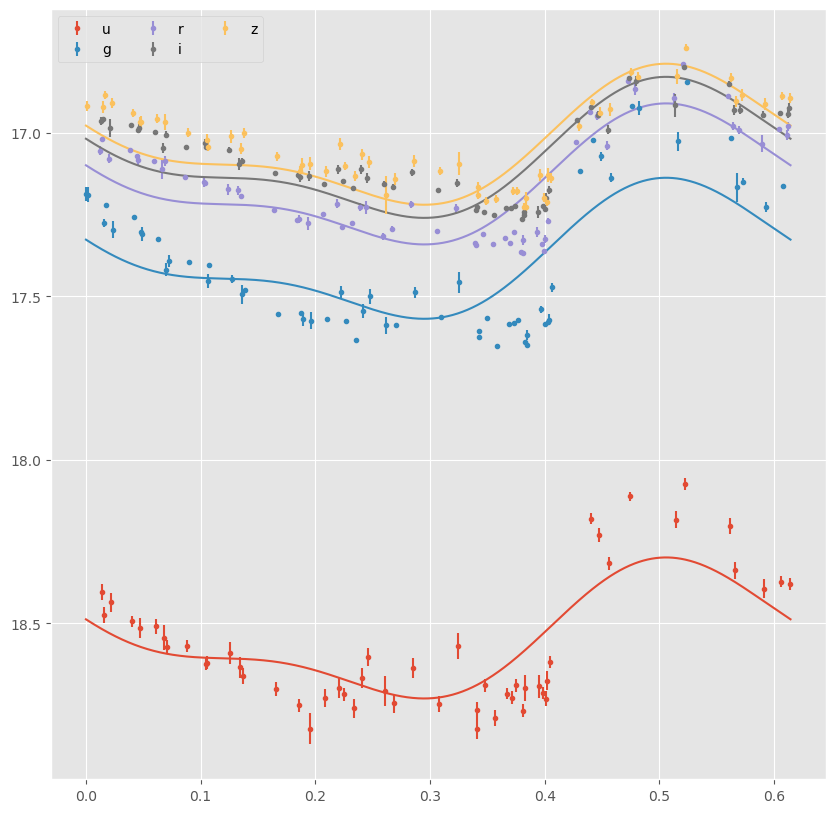

In [34]:
lcid = rrlyrae.ids[0]
fig = plt.figure(figsize=(10,10))
plot_model(LombScargleMultiband(Nterms_base=2, Nterms_band=0), lcid)

Note that this works well for this case because we don't expect $\omega$ to be bandpass dependent (why? because we understand the physics that drives the oscillations). It might not work so well where variability period is different from band to band (for quasars, for example).

### Classification

With parameters of a periodic model in hand, we can attempt to classify our sources.  Either using supervised methods if we have labeled examples or unsupervised methods if we do not.

The examples below show that a sample of variable stars can be divided into different groups.  The first plot shows an unsupervised clustering analysis and the second is a supervised GMMB classification.

We will learn more about this when we discuss machine learning.

![Ivezic, Figure 10.20](http://www.astroml.org/_images/fig_LINEAR_clustering_1.png)

![Ivezic, Figure 10.22](http://www.astroml.org/_images/fig_LINEAR_GMMBayes_1.png)

## Characterization: Temporally Localized Signals ($\S$ 10.4)

Let's begin with the case of a stationary signal with an event localized in time.
An example would be the signature of a [gravitational wave from LIGO](https://www.ligo.caltech.edu/news/ligo20160615).

In this case we know the expected shape of the signal and the noise properties are understood, so we can model the expected signal shape.  Specifically, we will identify the signal by using a **matched filter** (with MCMC to search for the parameter posteriors).

## Finding a chirp or burst in a time series

Imagine a stationary signal $y(t)=b_0+\epsilon$ with an injected signal at time $T$ (possibly followed by a decay to the original level $b_0$ over some unknown time period).

This injected signal could be a "burst" (your previous homework)

$$y(t)=b_0 + A\exp[−\alpha(t−T)]$$

or a ["chirp"](https://en.wikipedia.org/wiki/Chirp)

$$y(t)=b_0+A \sin[\omega t+\beta t^2].$$

Let's go back to Fourier analysis. We said that the power spectral density (PSD)
for a sinusoidal variation is delta function at that frequency (i.e. the PSD is 
the amplitude of the Fourier transform as a function of frequency). 

Here is a slightly more complex example: a chirp, where the frequency of variation
is steadily increasing with time. 

<img src="figures/PSDchirp.png" style="float: left; width: 90%; margin-right: 1%;"> 
 

In [35]:
# Change these parameters to see what effect they have on how
# well the system can be modeled.
N = 100
b0_true = 10
A_true = 5
beta_true = 0.01
omega_true = 0.1
sigma = 2.0

# Ivezic et al., Figure 10.26
def chirp(t, b0, beta, A, omega):
    return b0 + A * np.sin(omega * t + beta * t * t)

np.random.seed(10)

# Plot the functional form
t_tmp = np.linspace(0, 100, 10000)
y_tmp = chirp(t_tmp, b0_true, beta_true, A_true, omega_true)

# Generate the dataset, and overplot
t = np.sort(100 * np.random.random(N))
y_true = chirp(t, b0_true, beta_true, A_true, omega_true)
y_obs = np.random.normal(y_true, sigma)

def fig10_26():
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5), sharey=True)

    ax1.scatter(t, y_obs)
    ax1.set_ylabel("Flux (arbitrary units)")
    ax1.set_xlabel("t")
    ax1.set_title("Data only")

    ax2.plot(t_tmp, y_tmp, ls='--', color='gray')
    ax2.scatter(t, y_obs)
    ax2.set_xlabel("t")
    ax2.set_title("Data + truth")

    fig.tight_layout()

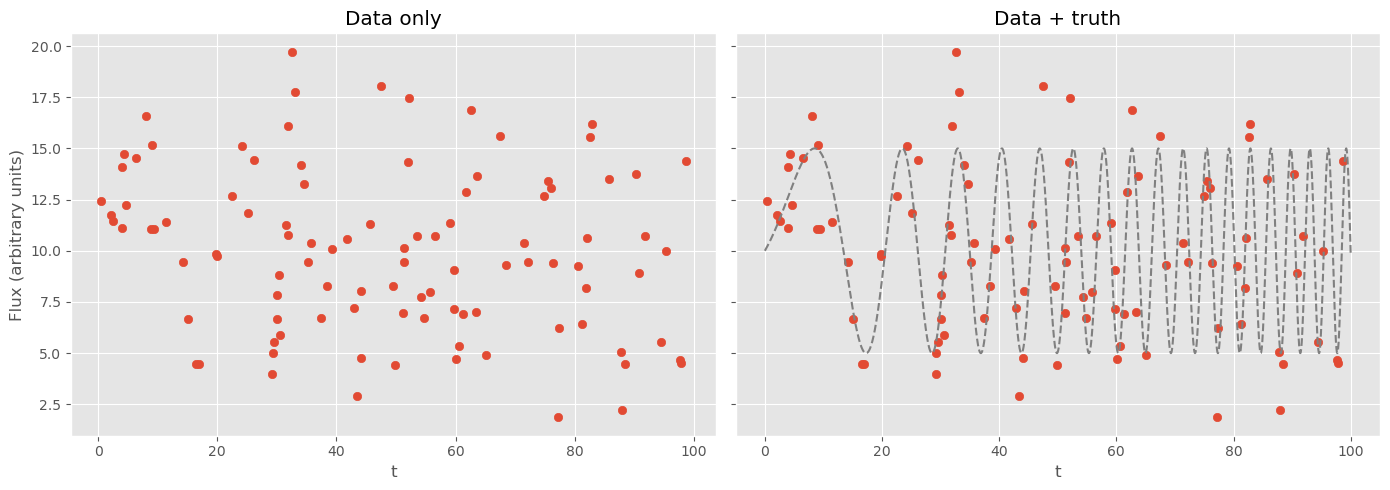

In [36]:
fig10_26()

## We'll estimate the model parameters using MCMC:

In [37]:
import pymc as pm
import arviz as az

# ----------------------------------------------------------------------
# Set up MCMC sampling
with pm.Model():
    b0 = pm.Uniform('b0', 0, 20, initval=10 * np.random.random())
    A = pm.Uniform('A', 0, 10, initval=10 * np.random.random())
    log_beta = pm.Uniform('log_beta', -5, 5, initval=-3.6)
    log_omega = pm.Uniform('log_omega', -5, 5, initval=-2.3)

    y = pm.Normal('y', mu=chirp(t, b0, np.exp(log_beta), A, np.exp(log_omega)),
                  sigma=sigma, observed=y_obs)

    # Choose the Metropolis-Hastings step rather than rely on the default
    step = pm.Metropolis()
    traces = pm.sample(draws=50000, tune=10000, step=step)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [b0]
>Metropolis: [A]
>Metropolis: [log_beta]
>Metropolis: [log_omega]


Output()

Sampling 4 chains for 10_000 tune and 50_000 draw iterations (40_000 + 200_000 draws total) took 8 seconds.


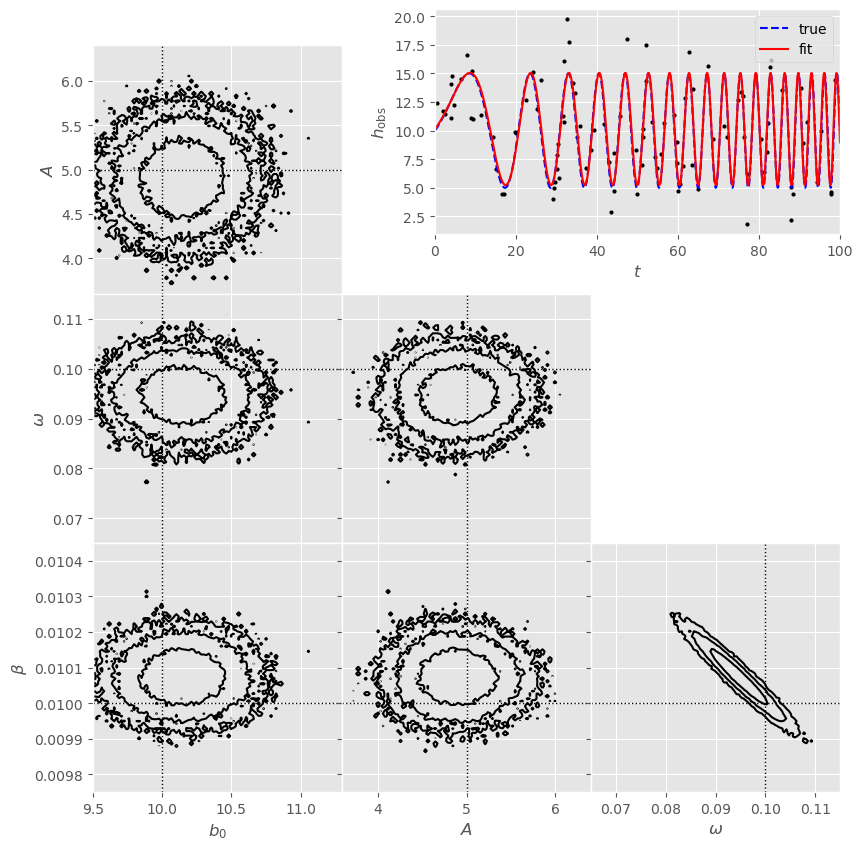

In [38]:
# summarize the results
df = az.extract(traces).to_dataframe()
df["omega"] = np.exp(df['log_omega'])
df["beta"] = np.exp(df['log_beta'])
del df["log_beta"]
del df["log_omega"]

labels = ['$b_0$', '$A$', r'$\omega$', r'$\beta$']
limits = [(9.5, 11.3), (3.6, 6.4), (0.065, 0.115), (0.00975, 0.01045)]
true = [b0_true, A_true, omega_true, beta_true]
b0_bfit = np.median(traces.posterior['b0'].values.flatten()) 
A_bfit = np.median(traces.posterior['A'].values.flatten()) 
omega_bfit = np.median(np.exp(traces.posterior['log_omega'].values.flatten()))
beta_bfit = np.median(np.exp(traces.posterior['log_beta'].values.flatten()))
                       
# plot                      
fig = plt.figure(figsize=(9, 9))
ax = plt.axes([0.5, 0.7, 0.45, 0.25])

# ----------------------------------------------------------------------
# Plot multiple panels with the traces
plt.scatter(t, y_obs, s=9, lw=0, c='k')

t_tmp = np.linspace(0, 100, 1001)
ax.plot(t_tmp, chirp(t_tmp, b0_true, beta_true, A_true, omega_true), '--', c='blue', label='true')
ax.plot(t_tmp, chirp(t_tmp, b0_bfit, beta_bfit, A_bfit, omega_bfit), '-k', c='red', label='fit')                     
#ax.plot(t_tmp, chirp(t_tmp, **df.median()), '-k', c='red', label='fit')
ax.legend()

plt.xlim(0, 100)
plt.xlabel('$t$')
plt.ylabel(r'$h_{\rm obs}$')

plot_mcmc([traces.posterior[ii].values.flatten() for ii in ['b0', 'A']]
          + [np.exp(traces.posterior['log_omega'].values.flatten()), np.exp(traces.posterior['log_beta'].values.flatten())],
          levels=[0.683, 0.955, 0.997], labels=labels, limits=limits, true_values=true, fig=fig,
          bins=100, bounds=[0.12, 0.08, 0.95, 0.91], colors='k')
plt.show()

#### Temporally Localized Signals: Summary


Temporally localized signals are those with an event localized in time (e.g., a stellar flare, or a gravitational wave event).

We can handle them with the standard model fitting techniques we've already learned about (either maximum likelihood -- matched filters when used in this context -- or Bayesian inference).



## Time Series Analysis: Stochastic Variability



We can compute power spectral density (PSD) for any time series. For illustration,
here are examples of time series where underlying PSD is a power law. 
The $PSD = 1/f^2$ case is called "red noise" and the $PSD = 1/f$ case is called 
"pink noise" (because a flat PSD is called white noise). 

These are famous examples of stochastic processes. The "red noise" process is 
also known as Brownian motion, and as random walk (or “drunkard’s walk”). The
"white noise", or noise of uncorrelated random variables with zero mean and 
constant variance, is also known as "thermal" or Johnson's noise. 

<img src="figures/PSDcolorednoise.png" style="float: left; width: 90%; margin-right: 1%;"> 
 


 
A few things to notice:
* The overall power (the amplitude) of the signal is determined by the power at low frequencies in the PSD. Those are set to the same value and thus the overall amplitude of the signal is similar.
* Because the power at high frequency is larger for $1/f$, that light curve looks noisier.
 

## Different stochastic processes

* A stochastic process with $1/f^2$ spectrum is known as random walk (if discrete) or Brownian motion (or, more accurately, Wiener process) if continuous. These physically occur when the value being observed is subjected to a series of independent changes of similar size. It's also sometimes called as **"red noise"**. Quasar variability exhibits $1/f^2$ properties at high frequencies (that is, short time scales, below a year or so). 
* A stochastic process with $1/f$ spectrum are sometimes called "long-term memory processes" (also sometimes know as **"pink noise"**). They have equal energy at all octaves (or over any other logarithmic frequency interval). This type of process has infinite variance and an undefined mean (remember the Lorentzian? this is similar.). 
* A process with a constant PSD is frequently referred to as **"white nose"** -- it has equal intensity at all frequencies. This is a process with no memory -- each measurement is independent of all others. 

### Damped Random Walk

DRW is described by a stochastic differential equation which includes a damping term that pushes $y(t)$ back towards the mean, hence the name **damped random walk**.   


Its  PSD is  
$$ PSD(f) \propto \frac{\tau^2 }{1+(2\pi f \tau)^2},$$
which means that a DRW is a $1/f^2$ process at high frequency ($\tau$ is characteristic time scale).  The *damped* part comes from the flat PSD at low frequency.

Light curves are strongly correlated a short timescales, but uncorrelated at long timescales. This is observed in optical variability of quasar continuum light; in fact, it works so well that one can use this model to distinguish quasars from stars, based solely on the variability they exhibit.

## Examples of Stochastic Processes

AstroML has [time series](http://www.astroml.org/modules/classes.html#module-astroML.time_series) and [Fourier](http://www.astroml.org/modules/classes.html#module-astroML.fourier) tools for generating light curves drawn from a power law in frequency space.  Note that these tools define $\beta = 1+2\alpha$  ($\beta=2$ for "red noise", or random
walk). 

Let's play with the code below to make a plot of counts vs. time and of the PSD vs. frequency for both a $1/f$ and a $1/f^2$ process.   

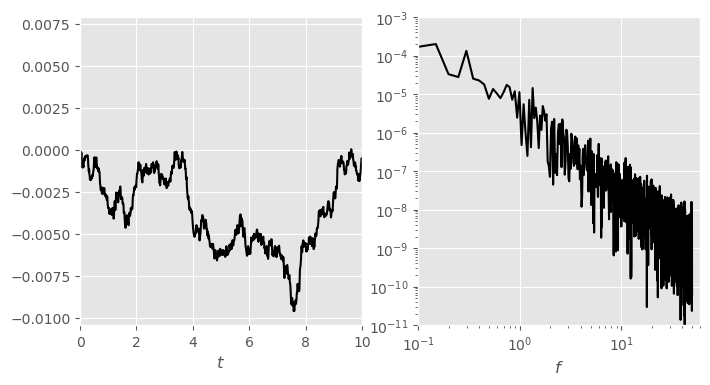

In [39]:
import numpy as np
from matplotlib import pyplot as plt
from astroML.time_series import generate_power_law
from astroML.fourier import PSD_continuous

N = 2014
dt = 0.01
beta = 2 ## Change this from 1 to 2 (or higher, or lower)

t = dt * np.arange(N)
y = generate_power_law(N, dt, beta) ## Complete
f, PSD = PSD_continuous(t, y) ## Complete
    
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(121)
ax1.plot(t, y, '-k')
ax1.set_xlim(0, 10)
ax1.set_xlabel(r'$t$')

ax2 = fig.add_subplot(122, xscale='log', yscale='log')
ax2.plot(f, PSD, '-k')   
ax2.set_xlim(1E-1, 60)
ax2.set_ylim(1E-11, 1E-3)
ax2.set_xlabel(r'$f$')

plt.show()

# Summary

Today we've learned about **time series**, and the techniques for estimation of their parameters. We've learned:

* How to decide if an object is variable (via $\chi^2$)
* Approximate methods for finding periods in periodic signals (periodograms)
* How to interpret periodograms
* Some periodogram generalizations
* How to estimate parameters of temporally localized signals (matched filter; standard model fitting techniques)
* Brief introduction to stochastic variability 

All these techniques give us estimates of parameter values (periods, amplitudes, light curve shape parameters, etc) for an object. When applied to thousands or millions of objects, we may begin to notice some similarities -- families of objects with similar periods, amplitudes of variability, colors, and so on. These similarities may indicate the same physics governs the variability in all these objects.

Historically, we've noticed such similarities "by eye". In the lectures to follow, we will look at techniques for quantitative identification of such similarities, leading us to topics of **clustering, classification, and machine learning**. 
